# Intro to PyGC + Graph Convolution Networks

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="torch_geometric")

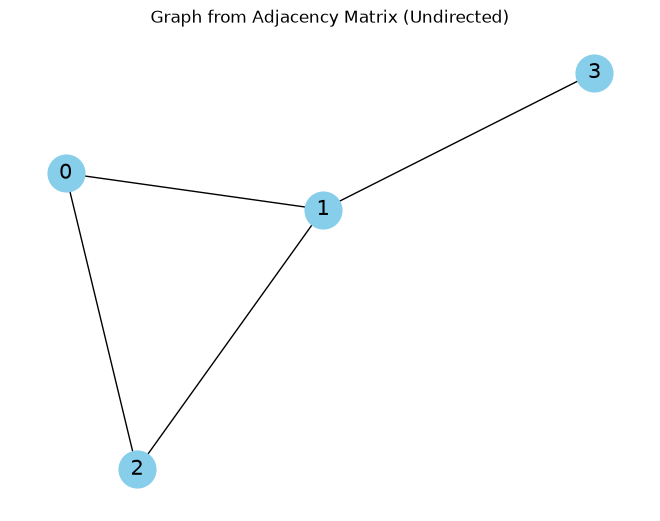

In [2]:
# Adjacency Matrix from Numpy
A = np.array([
    [0, 1, 1, 0],
    [1, 0, 1, 1],
    [1, 1, 0, 0],
    [0, 1, 0, 0]
])

# Create the Graph. The nodes will be labeled 0, 1, 2, 3
G = nx.from_numpy_array(A)

# 3. Visualize the graph
pos = nx.spring_layout(G)
nx.draw(
    G,
    pos, 
    with_labels=True,
    node_color='skyblue',
    node_size=700,
    edge_color='k',
    linewidths=1,
    font_size=15
    )
plt.title("Graph from Adjacency Matrix (Undirected)")
plt.show()

In [3]:
import torch
from torch_geometric.utils import (
    dense_to_sparse,
    to_dense_adj
)

A_np = np.array([
    [0, 1, 1, 0],
    [1, 0, 1, 1],
    [1, 1, 0, 0],
    [0, 1, 0, 0]
])

# Convertimos a Tensor de PyTorch (necesario para PyG)
A = torch.from_numpy(A_np)

print("="*40)
print(A)
print("="*40)

tensor([[0, 1, 1, 0],
        [1, 0, 1, 1],
        [1, 1, 0, 0],
        [0, 1, 0, 0]])


## Adyacencias en formato COO

Coordinate Format (COO) (https://docs.pytorch.org/docs/stable/sparse.html#sparse-coo-docs)

In [4]:
print("Adyacencias en formato COO")
# dense_to_sparse devuelve (edge_index, edge_attr)
edge_index, _ = dense_to_sparse(A)
print(edge_index)

Adyacencias en formato COO
tensor([[0, 0, 1, 1, 1, 2, 2, 3],
        [1, 2, 0, 2, 3, 0, 1, 1]])


## Reconstruimos la matriz densa de adyacencias

In [5]:
dense_adj = to_dense_adj(edge_index)
print(dense_adj)

tensor([[[0., 1., 1., 0.],
         [1., 0., 1., 1.],
         [1., 1., 0., 0.],
         [0., 1., 0., 0.]]])


## Features numericas de los nodos

In [6]:
df = pd.DataFrame(
    np.random.rand(4, 10),
    columns=[f'col_{i}' for i in range(10)]
    )

df

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9
0,0.894726,0.588687,0.285531,0.095569,0.906694,0.288887,0.176013,0.414333,0.487126,0.401678
1,0.716183,0.240712,0.153732,0.833800,0.691879,0.403554,0.662356,0.362031,0.329480,0.307622
2,0.557794,0.937418,0.470543,0.237630,0.696843,0.003421,0.237495,0.130823,0.999493,0.033519
3,0.548225,0.260917,0.886699,0.512112,0.121931,0.165833,0.969594,0.943295,0.477076,0.149344


In [7]:
df.to_numpy()

array([[0.89472634, 0.58868723, 0.28553097, 0.09556942, 0.90669421,
        0.28888673, 0.17601266, 0.41433259, 0.4871263 , 0.40167838],
       [0.71618312, 0.24071243, 0.15373244, 0.83379991, 0.69187854,
        0.40355419, 0.66235551, 0.36203069, 0.32947988, 0.307622  ],
       [0.55779406, 0.93741783, 0.47054283, 0.23763047, 0.69684265,
        0.003421  , 0.23749499, 0.13082344, 0.99949273, 0.0335192 ],
       [0.54822516, 0.26091746, 0.88669923, 0.51211204, 0.12193108,
        0.16583345, 0.96959398, 0.94329524, 0.47707624, 0.14934395]])

In [8]:
x = torch.tensor(df.to_numpy(), dtype=torch.float)

x

tensor([[0.8947, 0.5887, 0.2855, 0.0956, 0.9067, 0.2889, 0.1760, 0.4143, 0.4871,
         0.4017],
        [0.7162, 0.2407, 0.1537, 0.8338, 0.6919, 0.4036, 0.6624, 0.3620, 0.3295,
         0.3076],
        [0.5578, 0.9374, 0.4705, 0.2376, 0.6968, 0.0034, 0.2375, 0.1308, 0.9995,
         0.0335],
        [0.5482, 0.2609, 0.8867, 0.5121, 0.1219, 0.1658, 0.9696, 0.9433, 0.4771,
         0.1493]])

## Representación de Features Numéricas + Adjacencias

In [9]:
from torch_geometric.data import Data


In [10]:
data = Data(x=x, edge_index=edge_index)

In [11]:
data.x

tensor([[0.8947, 0.5887, 0.2855, 0.0956, 0.9067, 0.2889, 0.1760, 0.4143, 0.4871,
         0.4017],
        [0.7162, 0.2407, 0.1537, 0.8338, 0.6919, 0.4036, 0.6624, 0.3620, 0.3295,
         0.3076],
        [0.5578, 0.9374, 0.4705, 0.2376, 0.6968, 0.0034, 0.2375, 0.1308, 0.9995,
         0.0335],
        [0.5482, 0.2609, 0.8867, 0.5121, 0.1219, 0.1658, 0.9696, 0.9433, 0.4771,
         0.1493]])

In [12]:
data.edge_index

tensor([[0, 0, 1, 1, 1, 2, 2, 3],
        [1, 2, 0, 2, 3, 0, 1, 1]])

# 2. Ejemplo: Predicción del volumen de tráfico en Wikipedia (Regresión)

In [13]:
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn.functional as F
import torch_geometric.transforms as T
from torch_geometric.datasets import WikipediaNetwork
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_dense_adj, to_networkx

In [14]:
chameleon_transform = T.RandomNodeSplit(num_val=300, num_test=300)

In [15]:
dataset = WikipediaNetwork(
    root="../data/",
    name="chameleon",
    transform = chameleon_transform
)

data = dataset[0]

In [16]:
class GraphUtils:
    @staticmethod
    def create_adjacency_matrix(data):
        # Crea matriz de adyacencia
        adjacency = to_dense_adj(data.edge_index)[0]
        # Agrega una diagonal de unos (auto-referencia a nodos)
        adjacency = adjacency + torch.eye(len(adjacency))
        return adjacency

    @staticmethod
    def convert_to_networkx(graph, n_sample=None):
        g = to_networkx(graph, node_attrs=["x"])
        y = graph.y.numpy()
    
        if n_sample is not None:
            sampled_nodes  = random.sample(list(g.nodes), n_sample)
            g = g.subgraph(sampled_nodes)
            y = y[sampled_nodes]
    
        return g, y
    
    @staticmethod
    def plot_graph(g, y):
        plt.figure(figsize=(9, 7))
        nx.draw_spring(g, node_size=30, arrows=False, node_color=y)
        plt.show() 

In [17]:
print(data)

Data(x=[2277, 2325], edge_index=[2, 36101], y=[2277], train_mask=[2277], val_mask=[2277], test_mask=[2277])


In [18]:
print(f'Number of nodes: {data.num_nodes}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Number of nodes: 2277
Average node degree: 15.85
Number of training nodes: 1677
Training node label rate: 0.74
Has isolated nodes: False
Has self-loops: True
Is undirected: False


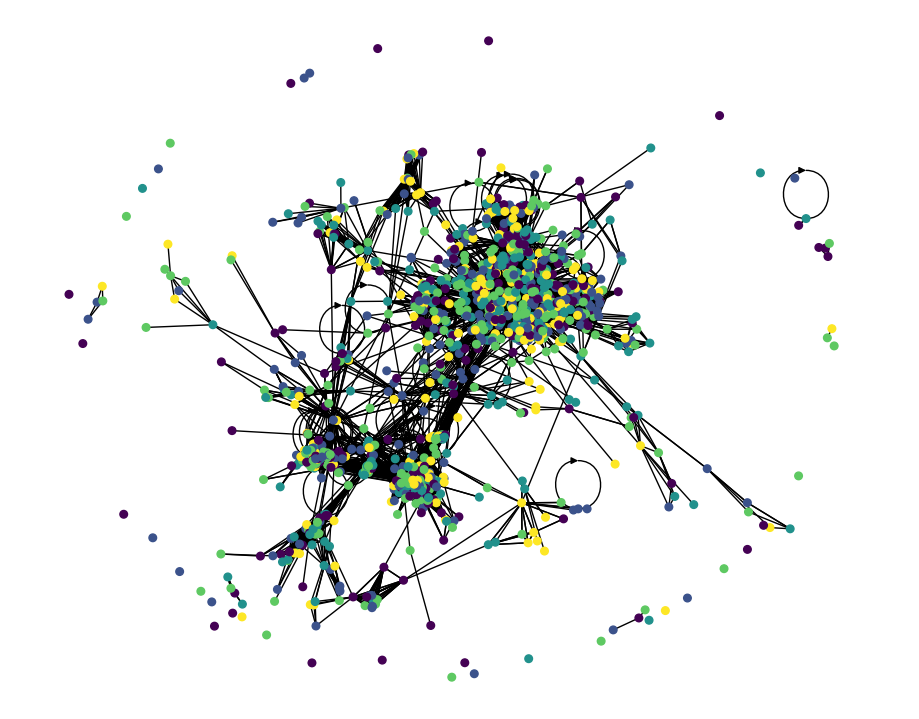

In [19]:
g, y = GraphUtils.convert_to_networkx(data, n_sample=1200)
GraphUtils.plot_graph(g, y)

In [20]:
df = pd.read_csv(
    '../data/chameleon/musae_chameleon_target.csv'
    )

In [21]:
df.sample(10)

,id,target
169,169,11768
558,558,618
721,721,329354
333,333,2555
98,98,607
1913,1913,645
1502,1502,445
782,782,28722
1799,1799,163
1896,1896,14480


In [40]:
len(data.y)

2277

In [41]:
df['target'].values

array([2.23299611, 3.90789484, 3.93287946, ..., 1.99563519, 4.35979755,
       2.44090908])

In [22]:
# Aplicamos logaritmo a la cantidad de visitas
df['target'] = df['target'].apply(lambda x:  np.log10(x))

In [47]:
df['target'].values

array([2.23299611, 3.90789484, 3.93287946, ..., 1.99563519, 4.35979755,
       2.44090908])

In [48]:
import torch

data.y = torch.tensor(df['target'].values)

In [54]:
class GCNRegressor(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gcn1 = GCNConv(dim_in, dim_h * 4)
        self.gcn2 = GCNConv(dim_h * 4, dim_h * 2)
        self.gcn3 = GCNConv(dim_h * 2, dim_h)
        self.linear = torch.nn.Linear(dim_h, dim_out)

    def forward(self, x, edge_index):
        h = self.gcn1(x, edge_index)
        h = torch.relu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.gcn2(h, edge_index)
        h = torch.relu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.gcn3(h, edge_index)
        h = torch.relu(h)
        h = self.linear(h)
        return h

    def fit(self, data, epochs):
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=0.02,
            weight_decay=5e-5
            )

        self.train()

        for epoch in range(epochs + 1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            loss = F.mse_loss(
                out.squeeze()[data.train_mask],
                data.y[data.train_mask].float()
                )
            loss.backward()
            optimizer.step()
            if epoch % 20 == 0:
                val_loss = F.mse_loss(
                    out.squeeze()[data.val_mask],
                    data.y[data.val_mask]
                    )
                print(f"Epoch {epoch:>3} | Train Loss: {loss:.5f} | Val Loss: {val_loss:.5f}")

    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        return F.mse_loss(out.squeeze()[data.test_mask], data.y[data.test_mask].float())

In [55]:
data.y

tensor([2.2330, 3.9079, 3.9329,  ..., 1.9956, 4.3598, 2.4409],
       dtype=torch.float64)

In [57]:
gcn_regressor = GCNRegressor(dataset.num_features, dim_h=64, dim_out=1)
print(gcn_regressor)

GCNRegressor(
  (gcn1): GCNConv(2325, 256)
  (gcn2): GCNConv(256, 128)
  (gcn3): GCNConv(128, 64)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)


In [58]:
gcn_regressor.fit(data, epochs=200)

Epoch   0 | Train Loss: 12.47068 | Val Loss: 12.23257
Epoch  20 | Train Loss: 5.40950 | Val Loss: 5.53347
Epoch  40 | Train Loss: 2.17545 | Val Loss: 2.29068
Epoch  60 | Train Loss: 0.63525 | Val Loss: 0.67447
Epoch  80 | Train Loss: 0.43326 | Val Loss: 0.57180
Epoch 100 | Train Loss: 0.36418 | Val Loss: 0.56683
Epoch 120 | Train Loss: 0.33771 | Val Loss: 0.56302
Epoch 140 | Train Loss: 0.31232 | Val Loss: 0.57941
Epoch 160 | Train Loss: 0.28938 | Val Loss: 0.52751
Epoch 180 | Train Loss: 0.27840 | Val Loss: 0.56334
Epoch 200 | Train Loss: 0.25913 | Val Loss: 0.63240


In [59]:
loss = gcn_regressor.test(data)
print(f'\nGCN test loss: {loss:.5f}\n')


GCN test loss: 0.72903



In [60]:
out = gcn_regressor(data.x, data.edge_index)
y_pred = out.squeeze()[data.test_mask].detach().numpy()
mse = mean_squared_error(data.y[data.test_mask], y_pred)
mae = mean_absolute_error(data.y[data.test_mask], y_pred)

In [61]:
print("Chameleon Dataset - Traffic Prediction - Test Set")
print(f'MSE = {mse:.4f} | RMSE = {np.sqrt(mse):.4f} | MAE = {mae:.4f}')

Chameleon Dataset - Traffic Prediction - Test Set
MSE = 0.7290 | RMSE = 0.8538 | MAE = 0.6548


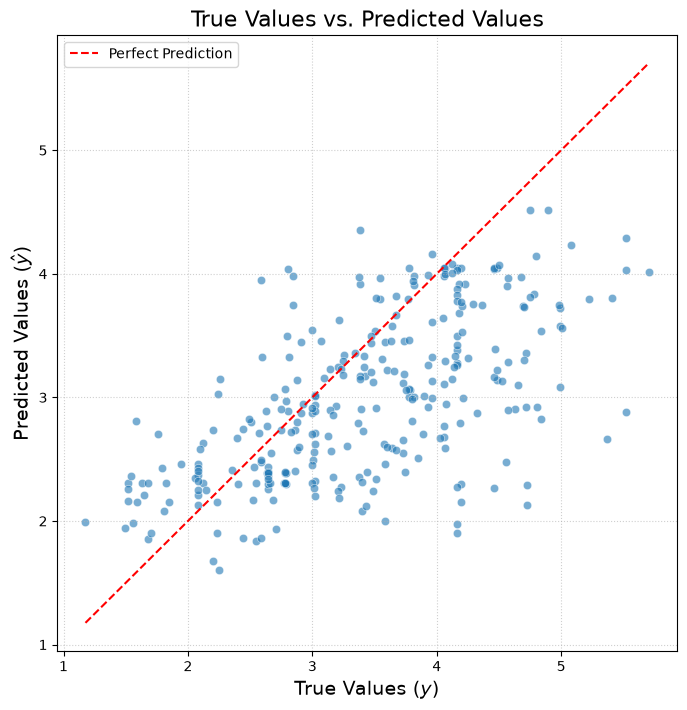

In [63]:
def plot_true_vs_predicted(y_true, y_pred):
    if hasattr(y_true, "detach"):
        y_true = y_true.detach().cpu().numpy()
    if hasattr(y_pred, "detach"):
        y_pred = y_pred.detach().cpu().numpy()
    
    # Ensure arrays are flattened (1D)
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    plt.figure(figsize=(8, 8))
    
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)

    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))

    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

    plt.title('True Values vs. Predicted Values', fontsize=16)
    plt.xlabel('True Values ($y$)', fontsize=14)
    plt.ylabel('Predicted Values ($\hat{y}$)', fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

plot_true_vs_predicted(data.y[data.test_mask], y_pred)

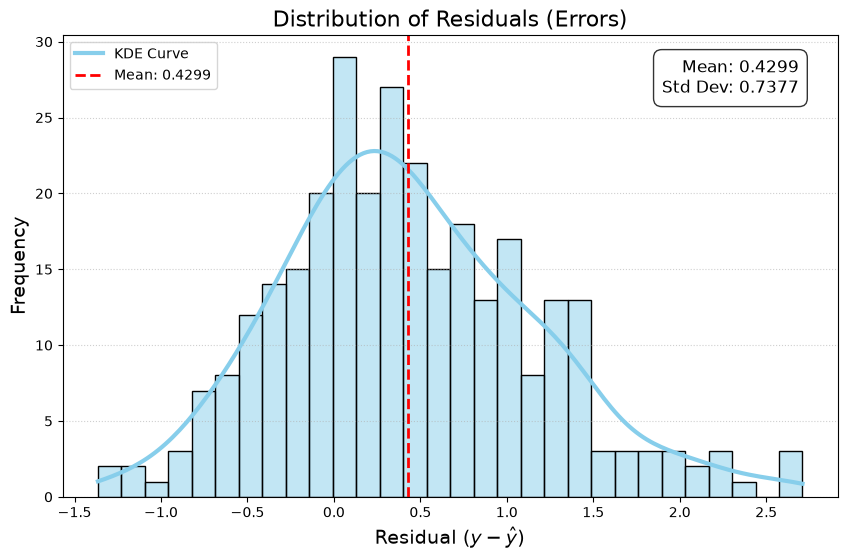

In [64]:
def plot_residuals_distribution(y_true, y_pred):
    if hasattr(y_true, "detach"):
        y_true = y_true.detach().cpu().numpy()
    if hasattr(y_pred, "detach"):
        y_pred = y_pred.detach().cpu().numpy()
    
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    residuals = y_true - y_pred
    
    # Calculate  statistics
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)

    plt.figure(figsize=(10, 6))
    
    # Create the histogram and KDE plot
    sns.histplot(
        residuals, 
        bins=30, 
        kde=True, 
        color='skyblue', 
        edgecolor='black',
        line_kws={'linewidth': 3, 'color': 'darkblue', 'label': 'KDE Curve'}
    )
    
    # Add a vertical line at the mean
    plt.axvline(
        x=mean_residual, 
        color='red', 
        linestyle='--', 
        linewidth=2, 
        label=f'Mean: {mean_residual:.4f}'
    )
    
    # Add titles and labels
    plt.title('Distribution of Residuals (Errors)', fontsize=16)
    plt.xlabel('Residual ($y - \hat{y}$)', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    
    # Add text box for statistics
    stats_text = f'Mean: {mean_residual:.4f}\nStd Dev: {std_residual:.4f}'
    plt.text(
        0.95, 0.95, 
        stats_text, 
        transform=plt.gca().transAxes, 
        verticalalignment='top', 
        horizontalalignment='right',
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.8)
    )
    
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6, axis='y')
    plt.show()

plot_residuals_distribution(data.y[data.test_mask], y_pred)